#01 数据集分析

该笔记本处于数据健全性检查阶段。目标是在大规模模型训练之前验证生成的数据、统计数据和分割行为是否有效。

In [1]:
from pathlib import Path
import sys
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import yaml

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DCD_ROOT = ROOT / "DCD_MUSIC"
# Keep project root (`ROOT`) ahead of DCD_MUSIC to avoid shadowing local `src` package.
if str(DCD_ROOT) not in sys.path:
    sys.path.append(str(DCD_ROOT))

FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8")
np.random.seed(42)
torch.manual_seed(42)

print(f"Project root: {ROOT}")
print(f"Figure output dir: {FIG_DIR}")

Project root: D:\LiLei\Python_projects\SubspaceNet_Update
Figure output dir: D:\LiLei\Python_projects\SubspaceNet_Update\figures


### 运行时环境和路径设置

这个单元格做了三件事：
1. 解析项目根目录并更新`sys.path`。
2. 附加“DCD_MUSIC”路径，同时保持本地“src”导入优先级。
3. 设置随机种子并创建图形输出目录以实现可重复性。

## 1) 配置审查 (YAML)

本部分将扁平化 YAML 配置文件并检查关键数据生成设置，例如系统参数、数据集大小、轨迹设置和分割比率。

In [2]:
def _flatten(prefix, obj):
    if isinstance(obj, dict):
        for k, v in obj.items():
            next_prefix = f"{prefix}.{k}" if prefix else str(k)
            yield from _flatten(next_prefix, v)
    else:
        yield prefix, obj

yaml_files = sorted((ROOT / "configs").rglob("*.yaml"))
if not yaml_files:
    raise FileNotFoundError("No YAML files found under configs/")

rows = []
for yfile in yaml_files:
    with yfile.open("r", encoding="utf-8") as f:
        cfg = yaml.safe_load(f) or {}
    for k, v in _flatten("", cfg):
        rows.append({
            "file": str(yfile.relative_to(ROOT)),
            "key": k,
            "value": v,
        })

cfg_df = pd.DataFrame(rows)
print(f"Found {len(yaml_files)} YAML files and {len(cfg_df)} flattened keys.")

focus_prefixes = (
    "system_model.",
    "dataset.",
    "trajectory.",
    "training.",
    "evaluation.",
)
focus_df = cfg_df[cfg_df["key"].str.startswith(focus_prefixes)].copy()
focus_df.sort_values(["file", "key"], inplace=True)
focus_df.head(80)

Found 26 YAML files and 1514 flattened keys.


,file,key,value
376,configs\Legacy\eta_scenario.yaml,dataset.create_data,True
374,configs\Legacy\eta_scenario.yaml,dataset.samples_size,1024
377,configs\Legacy\eta_scenario.yaml,dataset.save_dataset,False
375,configs\Legacy\eta_scenario.yaml,dataset.test_validation_train_split,"[0.2, 0.2, 0.6]"
380,configs\Legacy\eta_scenario.yaml,dataset.true_doa_test,None
...,...,...,...
457,configs\Legacy\nonlinear_tracking_config.yaml,training.training_objective,angle
458,configs\Legacy\nonlinear_tracking_config.yaml,training.use_wandb,False
454,configs\Legacy\nonlinear_tracking_config.yaml,training.weight_decay,1e-9
477,configs\Legacy\nonlinear_tracking_config.yaml,trajectory.enabled,True


### 如何阅读配置表

关键检查：
- `create_data` 和 `save_dataset` 是否符合您的工作流程？
- 轨迹噪声强度对于 DOA 范围是否过于激进？
- 对于当前样本量来说，分流比是否合理？

## 2) 构建小型分析数据集

本节通过覆盖内存中的样本大小和轨迹长度来创建轻量级分析数据集，因此我们可以快速迭代而无需触及生产配置。

Running on device:  cpu


Dataset trajectories: 128
Trajectory length: 30
One sample X shape [L, N, T]: (30, 8, 200)
Example source counts (first trajectory): [3, 3, 3, 3, 3, 3, 3, 3, 3, 3]


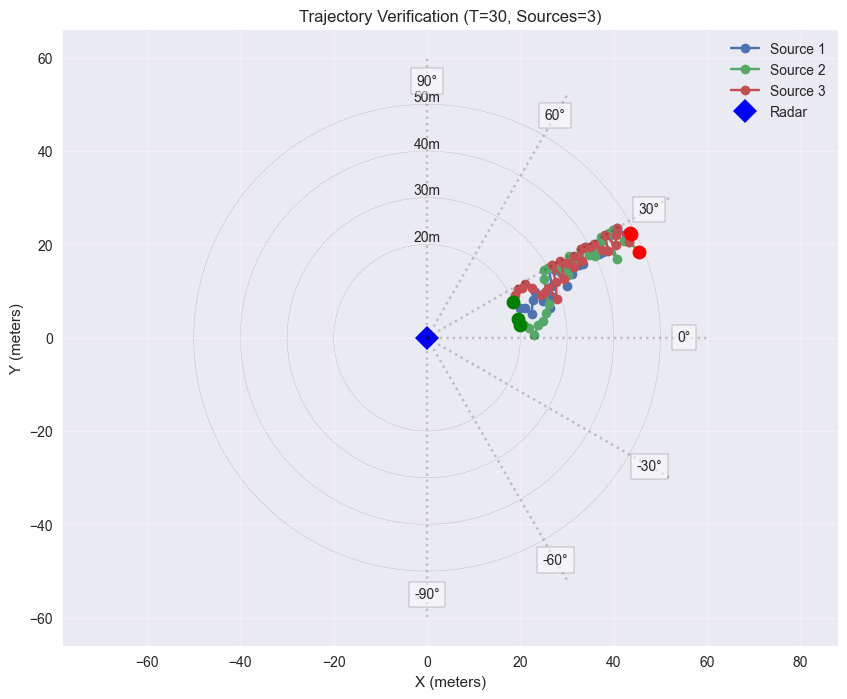

In [3]:
from src.data.trajectory import TrajectoryDataHandler
from config.loader import load_config
from config.factory import create_system_model

if not DCD_ROOT.exists() or not any(DCD_ROOT.iterdir()):
    raise RuntimeError(
        "DCD_MUSIC submodule appears empty. Run: git submodule update --init --recursive"
    )

config_path = ROOT / "configs" / "default_config.yaml"
config = load_config(str(config_path))

# Keep notebook runs fast and deterministic.
config.dataset.samples_size = 128
config.trajectory.trajectory_length = 30
config.trajectory.enabled = True

system_model = create_system_model(config)
handler = TrajectoryDataHandler(system_model_params=system_model.params, config=config)

dataset, samples_model = handler.create_dataset(
    samples_size=config.dataset.samples_size,
    trajectory_length=config.trajectory.trajectory_length,
    trajectory_type=config.trajectory.trajectory_type,
    save_dataset=False,
)

print(f"Dataset trajectories: {len(dataset)}")
print(f"Trajectory length: {dataset.trajectory_length}")
print(f"One sample X shape [L, N, T]: {tuple(dataset.time_series[0].shape)}")
print(f"Example source counts (first trajectory): {dataset.sources_num[0][:10]}")

### 输出解释

打印的值确认：
- 轨迹数量，
- 轨迹长度，
- 张量形状`[L，N，T]`，
- 源计数序列格式。

这在可视化之前验证了结构假设。

## 3) 可视化示例

本节重点介绍三种视觉诊断：
1. 轨迹级 DOA 行为，
2. 经验信噪比行为，
3.噪声强度分布。

### 3a) 置信区间为 95% 的平均 DOA 轨迹

该线是随时间变化的聚合平均 DOA，阴影区域是置信带。该图用于检测漂移、边界饱和和不稳定模式。

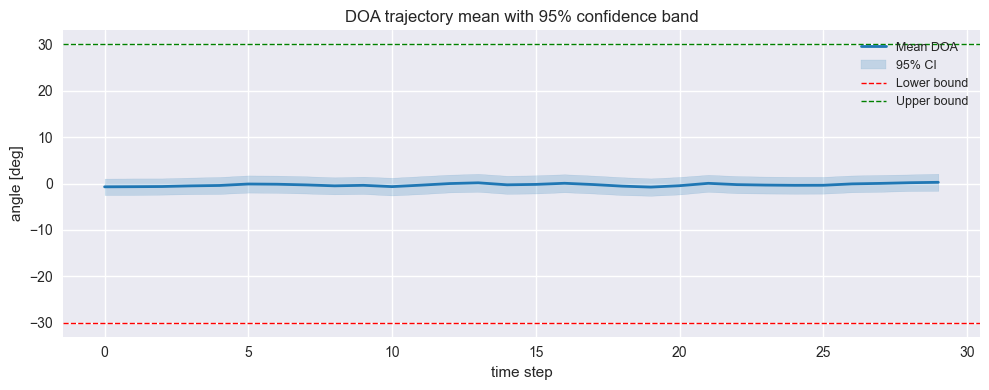

In [4]:
# 3a) Mean DOA trajectory with 95% confidence band (across all samples/sources)
trajectory_length = dataset.trajectory_length
angle_records = [[] for _ in range(trajectory_length)]

for i in range(len(dataset.labels)):
    for t in range(trajectory_length):
        m_t = int(dataset.sources_num[i][t])
        angles_t_deg = np.rad2deg(np.asarray(dataset.labels[i][t], dtype=np.float32)[:m_t])
        angle_records[t].extend(angles_t_deg.tolist())

means = []
ci95_low = []
ci95_high = []
for vals in angle_records:
    arr = np.asarray(vals, dtype=np.float32)
    n = max(1, arr.size)
    mean = float(np.mean(arr))
    std = float(np.std(arr, ddof=1)) if n > 1 else 0.0
    sem = std / np.sqrt(n)
    ci = 1.96 * sem
    means.append(mean)
    ci95_low.append(mean - ci)
    ci95_high.append(mean + ci)

x = np.arange(trajectory_length)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x, means, color="#1f77b4", linewidth=2.0, label="Mean DOA")
ax.fill_between(x, ci95_low, ci95_high, color="#1f77b4", alpha=0.2, label="95% CI")
ax.axhline(-config.system_model.doa_range / 2, color="r", linestyle="--", linewidth=1, label="Lower bound")
ax.axhline(config.system_model.doa_range / 2, color="g", linestyle="--", linewidth=1, label="Upper bound")
ax.set_title("DOA trajectory mean with 95% confidence band")
ax.set_xlabel("time step")
ax.set_ylabel("angle [deg]")
ax.legend(loc="best", fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "dataset_doa_mean_ci.png", dpi=180)
plt.show()

### 3b) 小提琴图的分布视图

小提琴图用于比较 DOA、SNR 和噪声代理分布。与普通直方图相比，它们为偏斜和多模态提供了更好的密度形状可见性。

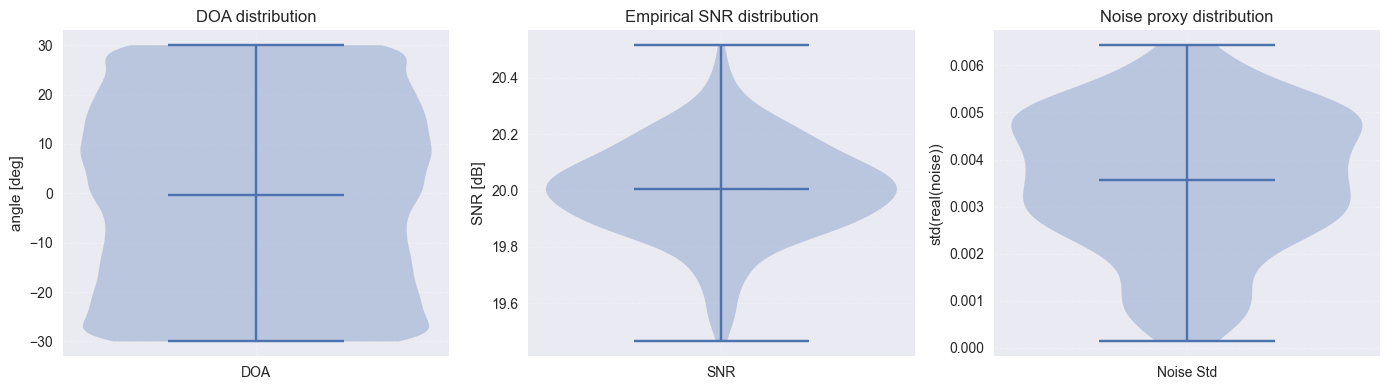

Collected SNR samples: 240
SNR mean/std [dB]: 20.005 / 0.171


In [5]:
# 3b) Violin distributions for global DOA / empirical SNR / noise std
snr_samples_db = []
noise_std_samples = []

max_eval_trajectories = min(24, len(dataset.labels))
for i in range(max_eval_trajectories):
    max_steps = min(10, len(dataset.labels[i]))
    for t in range(max_steps):
        y_rad = np.asarray(dataset.labels[i][t], dtype=np.float32)
        m_t = int(dataset.sources_num[i][t])
        samples_model.set_doa(y_rad.tolist(), m_t)
        if config.system_model.field_type.lower() != "far":
            samples_model.set_range(([20.0] * m_t), m_t)

        out = samples_model.samples_creation(
            noise_mean=0,
            noise_variance=1,
            signal_mean=0,
            signal_variance=1,
            source_number=m_t,
        )
        if not isinstance(out, tuple) or len(out) < 3:
            continue

        _, signal, noise = out[0], np.asarray(out[1]), np.asarray(out[2])
        sig_pwr = float(np.mean(np.abs(signal) ** 2))
        noise_pwr = float(np.mean(np.abs(noise) ** 2))
        if noise_pwr <= 0:
            continue
        snr_samples_db.append(10.0 * math.log10(sig_pwr / noise_pwr))
        noise_std_samples.append(float(np.std(np.real(noise))))

all_angles_deg = []
for i in range(len(dataset.labels)):
    for t in range(len(dataset.labels[i])):
        m_t = int(dataset.sources_num[i][t])
        all_angles_deg.extend(np.rad2deg(np.asarray(dataset.labels[i][t], dtype=np.float32)[:m_t]).tolist())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

parts0 = axes[0].violinplot([all_angles_deg], showmeans=True, showextrema=True)
axes[0].set_xticks([1])
axes[0].set_xticklabels(["DOA"])
axes[0].set_ylabel("angle [deg]")
axes[0].set_title("DOA distribution")

parts1 = axes[1].violinplot([snr_samples_db], showmeans=True, showextrema=True)
axes[1].set_xticks([1])
axes[1].set_xticklabels(["SNR"])
axes[1].set_ylabel("SNR [dB]")
axes[1].set_title("Empirical SNR distribution")

parts2 = axes[2].violinplot([noise_std_samples], showmeans=True, showextrema=True)
axes[2].set_xticks([1])
axes[2].set_xticklabels(["Noise Std"])
axes[2].set_ylabel("std(real(noise))")
axes[2].set_title("Noise proxy distribution")

for ax in axes:
    ax.grid(alpha=0.25, linestyle='--', linewidth=0.7)

fig.tight_layout()
fig.savefig(FIG_DIR / "dataset_distribution_violins.png", dpi=180)
plt.show()

print(f"Collected SNR samples: {len(snr_samples_db)}")
if snr_samples_db:
    print(f"SNR mean/std [dB]: {np.mean(snr_samples_db):.3f} / {np.std(snr_samples_db):.3f}")

## 4) 统计检查

本节计算关键统计数据：
- 角度平均值/方差/标准，
- 源计数分布，
- 边界命中率。

这些指标将视觉观察转化为定量检查。

,metric,value
0,num_angles,11520.000000
1,angle_mean_deg,-0.278057
2,angle_var_deg2,341.856476
3,angle_std_deg,18.489361
4,boundary_hit_rate,0.092188


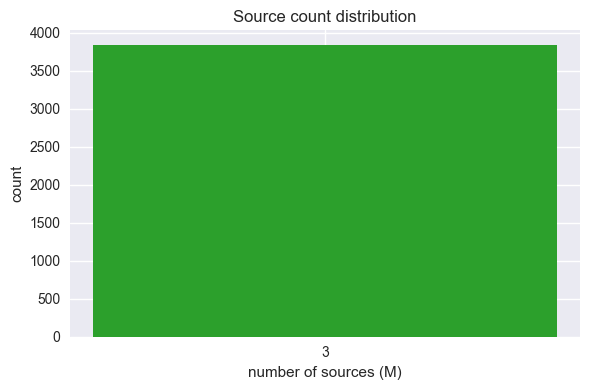

Source-count distribution:
source_count
3    3840


In [6]:
all_angles_deg = []
all_sources = []
for i in range(len(dataset.labels)):
    for t in range(len(dataset.labels[i])):
        m_t = int(dataset.sources_num[i][t])
        all_sources.append(m_t)
        all_angles_deg.extend(np.rad2deg(np.asarray(dataset.labels[i][t], dtype=np.float32)[:m_t]).tolist())

angles_deg = np.asarray(all_angles_deg, dtype=np.float32)
src_counts = pd.Series(all_sources, name="source_count")

angle_min = -config.system_model.doa_range / 2
angle_max = config.system_model.doa_range / 2
eps = 1e-3
boundary_hits = np.logical_or(np.abs(angles_deg - angle_min) <= eps, np.abs(angles_deg - angle_max) <= eps)
boundary_hit_rate = float(boundary_hits.mean()) if len(boundary_hits) else float("nan")

summary = pd.DataFrame(
    {
        "metric": [
            "num_angles",
            "angle_mean_deg",
            "angle_var_deg2",
            "angle_std_deg",
            "boundary_hit_rate",
        ],
        "value": [
            int(len(angles_deg)),
            float(np.mean(angles_deg)) if len(angles_deg) else np.nan,
            float(np.var(angles_deg)) if len(angles_deg) else np.nan,
            float(np.std(angles_deg)) if len(angles_deg) else np.nan,
            boundary_hit_rate,
        ],
    }
)
display(summary)

src_dist = src_counts.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(src_dist.index.astype(str), src_dist.values, color="#2ca02c")
ax.set_title("Source count distribution")
ax.set_xlabel("number of sources (M)")
ax.set_ylabel("count")
fig.tight_layout()
fig.savefig(FIG_DIR / "dataset_source_count_distribution.png", dpi=150)
plt.show()

print("Source-count distribution:")
print(src_dist.to_string())

### 如何解释指标

- 方差非常低可能表明数据过于静态。
- 非常高的方差可能表明噪声太大或不稳定的轨迹。
- 高边界命中率通常意味着来自轨迹设置的剪切压力。

## 5) 训练/验证/测试分割验证

本部分验证分割大小、重叠和完整索引覆盖，以防止训练前泄漏。

In [7]:
from torch.utils.data import random_split

test_ratio, val_ratio, train_ratio = config.dataset.test_validation_train_split
ratio_total = test_ratio + val_ratio + train_ratio
test_ratio, val_ratio, train_ratio = [r / ratio_total for r in (test_ratio, val_ratio, train_ratio)]

n_total = len(dataset)
train_len = max(1, int(n_total * train_ratio)) if n_total >= 3 else max(1, n_total - 2)
val_len = max(1, int(n_total * val_ratio)) if n_total >= 3 else 1
test_len = n_total - train_len - val_len
if test_len <= 0:
    test_len = 1
    if train_len > val_len:
        train_len -= 1
    else:
        val_len -= 1

train_ds, val_ds, test_ds = random_split(
    dataset,
    [train_len, val_len, test_len],
    generator=torch.Generator().manual_seed(42),
)

train_idx = set(train_ds.indices)
val_idx = set(val_ds.indices)
test_idx = set(test_ds.indices)

split_report = pd.DataFrame(
    {
        "split": ["train", "val", "test"],
        "size": [len(train_ds), len(val_ds), len(test_ds)],
        "ratio": [len(train_ds) / n_total, len(val_ds) / n_total, len(test_ds) / n_total],
    }
)
display(split_report)

print("Overlap checks")
print(f"train ∩ val: {len(train_idx & val_idx)}")
print(f"train ∩ test: {len(train_idx & test_idx)}")
print(f"val ∩ test: {len(val_idx & test_idx)}")
print(f"covered indices: {len(train_idx | val_idx | test_idx)} / {n_total}")

,split,size,ratio
0,train,76,0.593750
1,val,25,0.195312
2,test,27,0.210938


Overlap checks
train ∩ val: 0
train ∩ test: 0
val ∩ test: 0
covered indices: 128 / 128


### 常见的拆分陷阱

- 比率舍入可能会扭曲微小的数据集。
- 基于时间的分割需要与随机分割不同的泄漏检查。
- 种子必须固定以确保重现性。

## 6) 导出摘要

本节列出了导出的图形，并充当分析输出的可重现工件索引。

In [8]:
exported = sorted([p.name for p in FIG_DIR.glob("dataset_*.png")])
print("Exported figures:")
for name in exported:
    print(f"- {name}")

Exported figures:
- dataset_distribution_violins.png
- dataset_doa_mean_ci.png
- dataset_doa_trajectory.png
- dataset_noise_snr_distribution.png
- dataset_source_count_distribution.png


## 后续步骤

推荐顺序：
1.在当前配置下稳定这些检查，
2.增加样本量以验证稳健性，
3. 将稳定检查迁移到脚本/测试管道中。